In [2]:
!pip install matplotlib==3.8.4 seaborn==0.13.2 --user

  Using cached matplotlib-3.8.4-cp312-cp312-win_amd64.whl.metadata (5.9 kB)
Using cached matplotlib-3.8.4-cp312-cp312-win_amd64.whl (7.7 MB)


In [2]:
!pip install numpy==1.26.4 --user

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.32.0 requires packaging<24,>=16.8, but you have packaging 26.0 which is incompatible.
streamlit 1.32.0 requires pandas<3,>=1.3.0, but you have pandas 3.0.1 which is incompatible.
streamlit 1.32.0 requires pillow<11,>=7.1.0, but you have pillow 12.1.1 which is incompatible.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All fixed 👍")

All fixed 👍


In [5]:
import pandas as pd
import numpy as np

In [6]:
## Load dataset
df = pd.read_csv("adult_with_headers.csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
## Basic Exploration
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.5 MB


In [8]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [10]:
## Handle Missing Values
df.replace(" ?", np.nan, inplace=True)
df.dropna(inplace=True)

In [12]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [13]:
## SCALING
## Standard Scaling
scaler = StandardScaler()

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

In [14]:
## Min-Max Scaling
minmax = MinMaxScaler()

df[num_cols] = minmax.fit_transform(df[num_cols])

In [15]:
## ENCODING
## Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

C:\Users\Admin\AppData\Local\Temp\ipykernel_82712\2775999981.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [16]:
df['income_per_age'] = df['fnlwgt'] / (df['age'] + 1)
df['hours_per_age'] = df['hours_per_week'] / (df['age'] + 1)

In [17]:
df['log_fnlwgt'] = np.log1p(df['fnlwgt'])

In [18]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05)

df['outlier'] = iso.fit_predict(df)

df = df[df['outlier'] == 1]

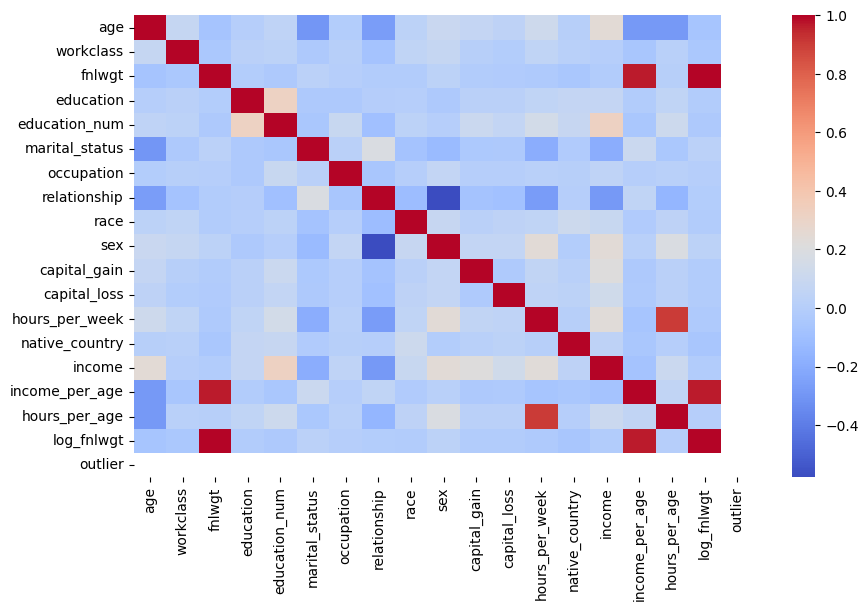

In [19]:
## Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.show()

In [20]:
## PPS (Predictive Power Score)
!pip install ppscore

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for ppscore: filename=ppscore-1.3.1-py2.py3-none-any.whl size=13215 sha256=90a75a2ae5ca85e57943c886f5ca4ccc59afd1cf9f28fad993a8ca8e97c635a6
  Stored in directory: c:\users\admin\appdata\local\pip\cache\wheels\84\0d\d6\ec295c574356939e9877f87c4eb195ba97440b0cd97cadf32a
Successfully built ppscore


In [22]:
import ppscore as pps

pps.matrix(df)

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.0,predict_itself,True,NaN,0.000000,1.000000,None
1,age,workclass,0.0,regression,True,mean absolute error,0.431600,0.552269,DecisionTreeRegressor()
2,age,fnlwgt,0.0,regression,True,mean absolute error,0.048474,0.049078,DecisionTreeRegressor()
3,age,education,0.0,regression,True,mean absolute error,2.623200,2.702272,DecisionTreeRegressor()
4,age,education_num,0.0,regression,True,mean absolute error,0.121280,0.123505,DecisionTreeRegressor()
...,...,...,...,...,...,...,...,...,...
356,outlier,income,0.0,regression,True,mean absolute error,0.232600,0.357018,DecisionTreeRegressor()
357,outlier,income_per_age,0.0,regression,True,mean absolute error,0.040344,0.040713,DecisionTreeRegressor()
358,outlier,hours_per_age,0.0,regression,True,mean absolute error,0.067127,0.067176,DecisionTreeRegressor()
359,outlier,log_fnlwgt,0.0,regression,True,mean absolute error,0.043210,0.043271,DecisionTreeRegressor()


## Conclusion 

Data preprocessing improved data quality
Missing values handled and features scaled
Encoding converted categorical data into numeric form
Feature engineering enhanced model features
Outliers were removed using Isolation Forest
Correlation and PPS helped understand feature relationships